#  CNN Fashion MNIST

* 본 파일은 GPU 런타임으로 연결됩니다.
* 경우에 따라서는 GPU 연결이 원활하지 않을 수도 있습니다.

## 1.환경준비

### (1) 라이브러리 로딩

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random as rd

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Input
from keras.backend import clear_session
from keras.optimizers import Adam
from keras.datasets import mnist, fashion_mnist

* 함수 만들기

In [2]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err')
    plt.plot(history['val_loss'], label='val_err')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (2) 데이터로딩

![fashion class](https://user-images.githubusercontent.com/60168331/117663987-35e42e00-b1dc-11eb-88c7-64db3b4fbff0.png)

In [3]:
# 케라스 데이터셋으로 부터 fashion_mnist 불러오기
(x_train, y_train), (x_val, y_val) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
x_train.shape, y_train.shape

((60000, 28, 28), (60000,))

In [5]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

## 2 데이터 살펴보기

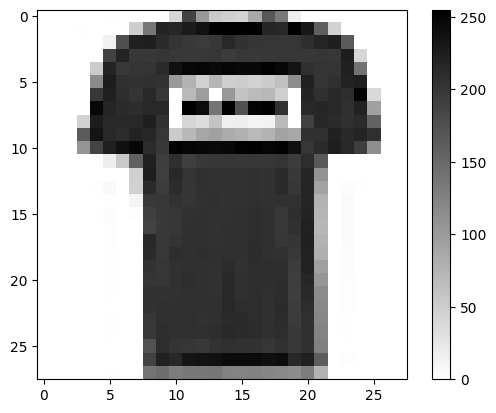

In [6]:
# 아래 숫자를 바꿔가며 화면에 그려 봅시다.
n = 1

plt.figure()
plt.imshow(x_train[n], cmap=plt.cm.binary)
plt.colorbar()
plt.show()

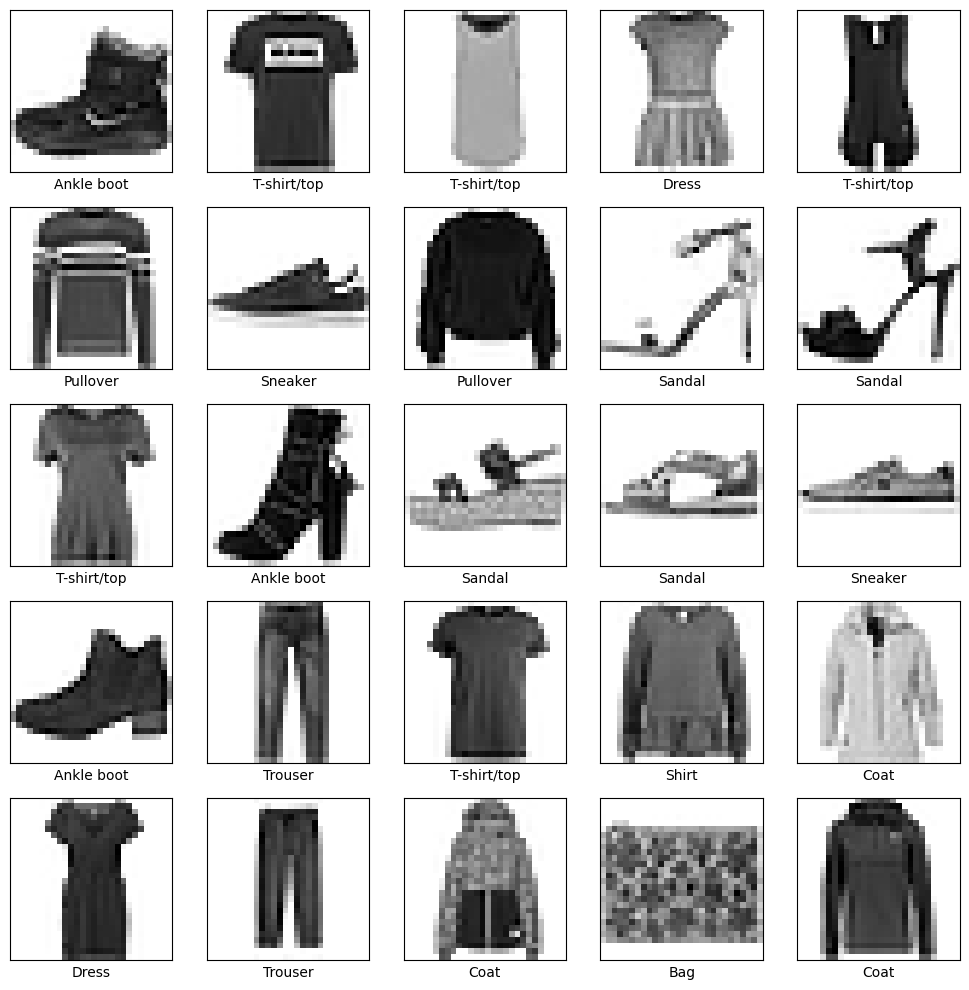

In [7]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.tight_layout()
plt.show()

## 3.데이터 준비

* CNN은 3차원 구조의 이미지(데이터셋은 4차원)를 입력해야 합니다.(input_shape)

In [8]:
x_train.shape, x_val.shape

((60000, 28, 28), (10000, 28, 28))

* reshape를 이용하여 다음과 같이 변환해 봅시다.
    * x_train.shape : (60000, 28, 28, 1)
    * x_val.shape : (10000, 28, 28, 1)

In [9]:
x_train = x_train.reshape(60000,28,28,1)
x_val = x_val.reshape(10000,28,28,1)

* Scaling : Min-Max
    * 0-255 값으로 되어 있는 데이터를 0-1사이 값으로 변환
    * x_train, x_val를 그냥 255로 나누면 됨

In [10]:
x_train = x_train / 255.
x_test = x_val / 255.

## 4.CNN 모델링

* 아래 그림의 구조대로 모델을 설계하고 학습해 봅시다.
* learning_rate = 0.0001

![](https://github.com/DA4BAM/image/blob/main/cnn_mnist3.png?raw=true)

In [15]:
clear_session()

model1 = Sequential([Input(shape = (28, 28, 1)),
                    Conv2D(32, kernel_size=3, padding='same', activation ='relu'),
                    MaxPooling2D(pool_size = 2),
                    Conv2D(64, kernel_size = 3, padding='same', activation = 'relu'),
                    MaxPooling2D(pool_size = 2),
                    Flatten(),
                    Dense(128, activation = 'relu'),
                    Dense(10, activation = 'softmax')
])

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model1.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy')

history = model1.fit(x_train, y_train, epochs = 15,
                    validation_split=0.2).history

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.9164 - val_loss: 0.4621
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4223 - val_loss: 0.3819
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.3644 - val_loss: 0.3534
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.3357 - val_loss: 0.3546
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.3138 - val_loss: 0.3129
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.2905 - val_loss: 0.3098
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.2822 - val_loss: 0.2859
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2662 - val_loss: 0.2849
Epoch 9/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2683 - val_loss: 0.2776
Epoch 10/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2543 - val_loss: 0.2676
Epoch 11/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2372 - val_loss: 0.2663
Epoch 12/15
1500/1500 ━━━━━━━━

* 학습결과 그래프

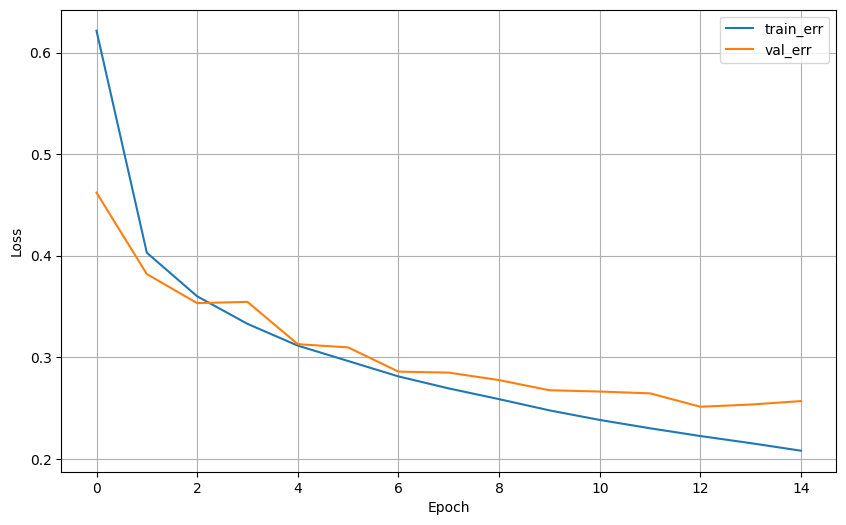

In [17]:
dl_history_plot(history)

* 예측 및 평가

In [18]:
pred1 = model1.predict(x_val)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [19]:
pred1 = pred1.argmax(axis=1)

In [38]:
print(confusion_matrix(y_val, pred1))
print('-'*60)
print(classification_report(y_val, pred1, digits = 4, target_names=class_names))

[[751   5  24  12  28   0 159   0  21   0]
 [  0 990   0   2   5   0   0   0   3   0]
 [  8   3 795   3 129   0  58   0   4   0]
 [  4  55  11 784 104   0  35   0   7   0]
 [  0   2  31   5 926   0  32   0   4   0]
 [  0   0   0   0   0 992   0   5   0   3]
 [ 61   5  50  15 147   0 706   0  16   0]
 [  0   0   0   0   0  62   0 831   1 106]
 [  2   2   0   1   3   3   0   2 987   0]
 [  0   0   0   0   0  12   1  11   0 976]]
------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top     0.9092    0.7510    0.8226      1000
     Trouser     0.9322    0.9900    0.9602      1000
    Pullover     0.8727    0.7950    0.8320      1000
       Dress     0.9538    0.7840    0.8606      1000
        Coat     0.6900    0.9260    0.7908      1000
      Sandal     0.9280    0.9920    0.9589      1000
       Shirt     0.7124    0.7060    0.7092      1000
     Sneaker     0.9788    0.8310    0.8989      1000
         Bag     0.94

## 4-2 모델링2

In [27]:
clear_session()

model2 = Sequential([Input(shape = (28, 28, 1)),
                    Conv2D(32, kernel_size=3, padding='same', activation ='relu'),
                    MaxPooling2D(pool_size = 2),
                    Conv2D(64, kernel_size = 3, padding='same', activation = 'relu'),
                    MaxPooling2D(pool_size = 2),
                    Conv2D(128, kernel_size = 3, padding='same', activation = 'relu'),
                    MaxPooling2D(pool_size = 2),
                    Flatten(),
                    Dense(512, activation = 'relu'),
                    Dense(128, activation = 'relu'),
                    Dense(10, activation = 'softmax')
])

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 749,962 (2.86 MB)

 Trainable params: 749,962 (2.86 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model2.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy')

history = model2.fit(x_train, y_train, epochs = 15,
                    validation_split=0.2).history

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.9864 - val_loss: 0.4770
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.4421 - val_loss: 0.3881
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.3706 - val_loss: 0.3549
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.3296 - val_loss: 0.3232
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.3014 - val_loss: 0.2916
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2789 - val_loss: 0.2863
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2612 - val_loss: 0.2670
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2426 - val_loss: 0.2636
Epoch 9/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2278 - val_loss: 0.2567
Epoch 10/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2199 - val_loss: 0.2610
Epoch 11/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2066 - val_loss: 0.2466
Epoch 12/15
1500/1500 ━━━━━━

* 학습결과 그래프

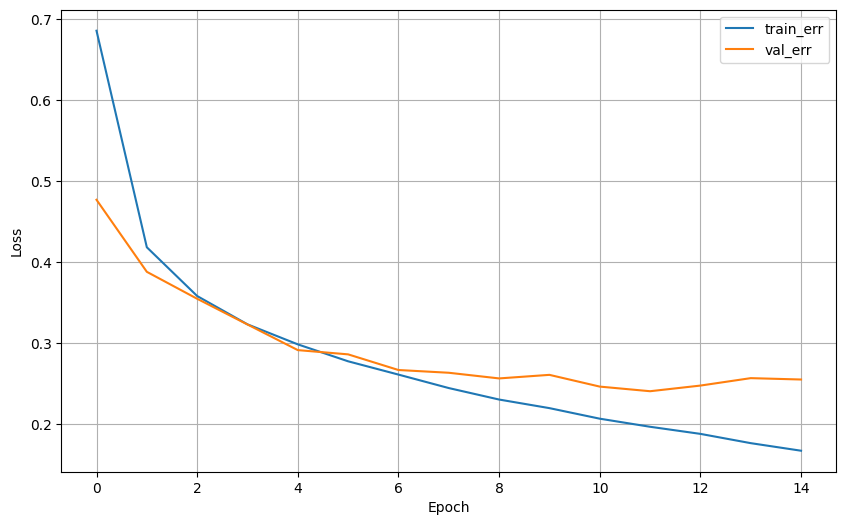

In [29]:
dl_history_plot(history)

* 예측 및 평가

In [30]:
pred2 = model2.predict(x_val)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [31]:
pred2 = pred2.argmax(axis=1)

In [39]:
print(confusion_matrix(y_val, pred2))
print('-'*60)
print(classification_report(y_val, pred2, digits = 4, target_names=class_names))

[[851   3  14   7  10   0  92   0  23   0]
 [  1 990   0   3   4   0   0   0   2   0]
 [ 10   3 797   3 125   0  56   0   6   0]
 [ 28  46  17 812  59   0  26   0  12   0]
 [  0   2  28   9 936   0  19   0   6   0]
 [  1   0   0   0   0 933   1  33  23   9]
 [104   5  48  15 167   0 646   0  15   0]
 [  0   0   0   0   0   2   0 973  11  14]
 [  2   1   1   0   2   1   0   0 993   0]
 [  0   0   0   0   0   7   1  61   2 929]]
------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top     0.8536    0.8510    0.8523      1000
     Trouser     0.9429    0.9900    0.9659      1000
    Pullover     0.8807    0.7970    0.8367      1000
       Dress     0.9564    0.8120    0.8783      1000
        Coat     0.7183    0.9360    0.8129      1000
      Sandal     0.9894    0.9330    0.9604      1000
       Shirt     0.7681    0.6460    0.7018      1000
     Sneaker     0.9119    0.9730    0.9415      1000
         Bag     0.90

## 5.틀린그림 찾아보기
위 모델의 결과에서 틀린 그림을 살펴 봅시다.

In [33]:
idx = (y_val != pred2)
x_val_wr = x_val[idx]
y_val_wr = y_val[idx]
pred_wr = pred2[idx]

x_val_wr = x_val_wr.reshape(-1,28,28)
print(x_val_wr.shape)

(1140, 28, 28)


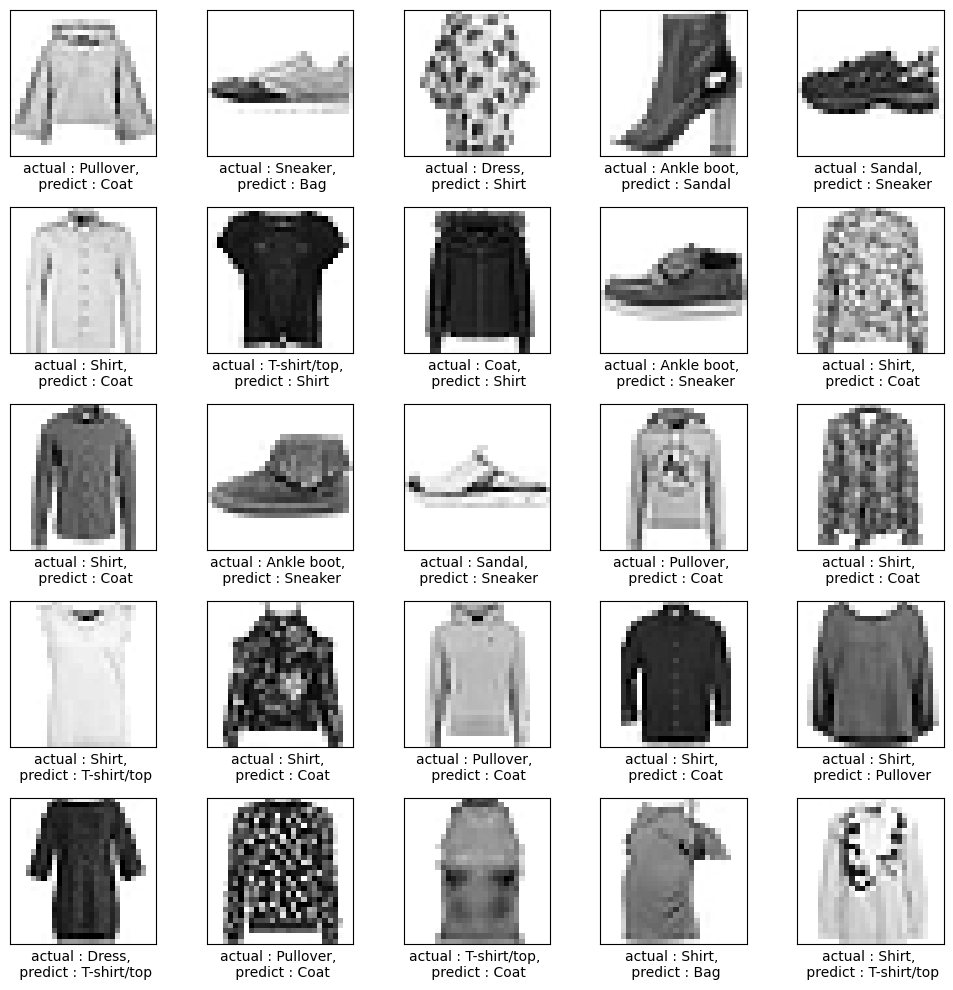

In [34]:
idx = rd.sample(range(x_val_wr.shape[0]),25)
x_temp = x_val_wr[idx]
y_temp = y_val_wr[idx]
p_temp = pred_wr[idx]

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_temp[i], cmap=plt.cm.binary)
    plt.xlabel(f'actual : {class_names[y_temp[i]]}, \n predict : {class_names[p_temp[i]]}')
plt.tight_layout()
plt.show()

## 6.손으로 그린 그림으로 예측해 봅시다.

In [40]:
import cv2
from google.colab.patches import cv2_imshow

* 그림판에서 손으로 그린 그림을 업로드 합니다.

In [41]:
# 다음 코드를 실행해서 파일을 업로드 합니다.
from google.colab import files
uploaded = files.upload()

Saving t_shirt.png to t_shirt.png


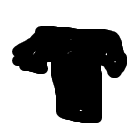

(140, 140)


In [42]:
# 파일 열기 : 아래 파일 이름은 여러분의 파일로 수정합니다.
img = cv2.imread('t_shirt.png', cv2.IMREAD_GRAYSCALE)
cv2_imshow(img)
print(img.shape)

In [43]:
# 크기 조절하기
img = cv2.resize(255-img, (28, 28))
print(img.shape)
cv2_imshow(img)

(28, 28)


In [44]:
test_num = img.reshape(1,28,28,1)
pred = model2.predict(test_num)
pred_1 = pred.argmax(axis=1)
print(class_names[pred_1[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 639ms/step
Shirt
